# Retail Sales & Profit Analysis: Business Insights from the Superstore Dataset

## Project Overview

This project analyzes retail sales data from a global superstore to identify key business trends, evaluate sales and profitability, and generate actionable recommendations for business growth.

The analysis focuses on understanding customer segment performance, regional performance, product profitability, discount patterns, and sales distribution using Python and data visualization techniques.

---

## Business Objective

The objective of this analysis is to answer the following business questions:

- Which regions generate the highest sales and profits?
- Which product categories are most profitable?
- Which customer segments contribute the most revenue?
- Which product categories and sub-categories are contributing to profitability issues?
- How can the company improve profitability?

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

#Better visualization style
sns.set_style("whitegrid")

In [2]:
# Load Dataset
df = pd.read_csv('/kaggle/input/datasets/pulkitdehariya/sample-superstore-dataset/SampleSuperstore.csv')

In [3]:
# Display First Five Rows

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 13)

### Observation

The dataset contains **9,994 records** and **13 columns**, providing sufficient data to analyze retail sales, customer segments, product categories, and profitability across different regions.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## Data Understanding

### Observations

- The dataset contains **9,994 retail transactions** and **13 columns**.
- There are **no missing values**, indicating good data quality.
- The dataset includes:
  - 8 categorical columns
  - 2 integer columns
  - 3 numerical columns
- The numerical columns (`Sales`, `Discount`, and `Profit`) will be the primary focus for business performance analysis.
- The categorical columns will help compare performance across regions, customer segments, shipping modes, and product categories.

In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Summary Statistics - Key Observations

### Sales
- The average sales amount is **229.86**, while the maximum transaction reaches **22,638.48**.
- This indicates the presence of a few exceptionally large orders.

### Quantity
- Customers purchase an average of **3.79 items** per transaction.
- Most orders contain a relatively small number of products.

### Discount
- The average discount is **15.6%**, with some products discounted by up to **80%**.
- Further analysis is required to determine whether high discounts negatively affect profitability.

### Profit
- The average profit per transaction is **28.66**.
- Some transactions generated significant losses (minimum profit = **-6599.98**), suggesting that certain products or discount strategies may be reducing profitability.

In [7]:
# Checking Missing Values
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

### Missing Values

No missing values were found in any column. Therefore, no imputation or removal of records was required.

In [8]:
# Checking Duplicate Values
df.duplicated().sum()

np.int64(17)

Here we find 17 duplicate values that will distrub our analysis

In [9]:
# Removing Duplicate Rows
df = df.drop_duplicates()

Here we removing the duplicate values so our analysis will be smooth

In [10]:
df.shape

(9977, 13)

## Data Cleaning

### Duplicate Records

The dataset contained **17 duplicate records**, which were removed to prevent duplicated transactions from influencing business insights.

After removing duplicates, the dataset contains **9,977 unique transactions**.

### Data Quality Summary

- Missing Values: **0**
- Duplicate Records Removed: **17**
- Final Dataset Size: **9,977 rows × 13 columns**

The dataset is now clean and ready for exploratory data analysis.

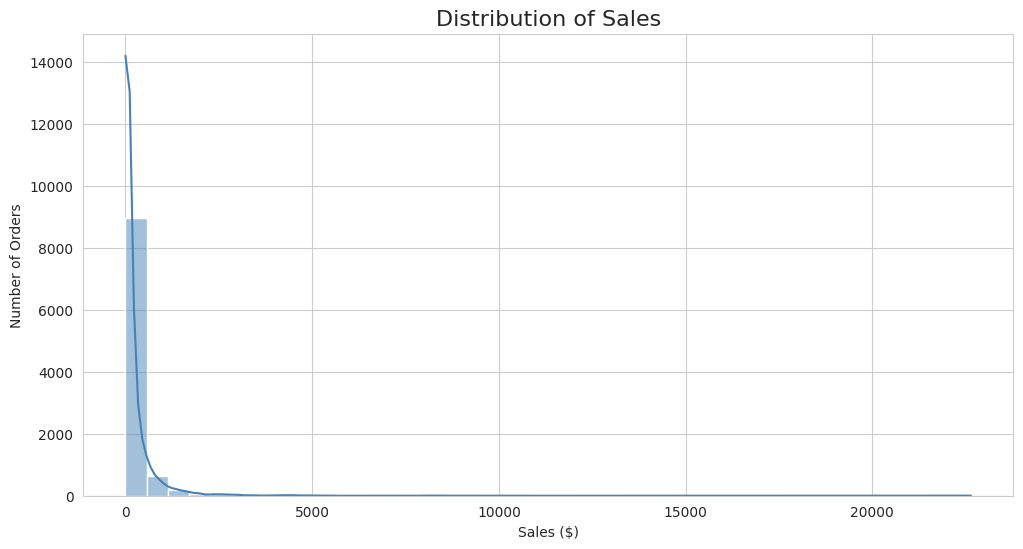

Mean Sales : 230.15
Median Sales : 54.82


In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='Sales',
    bins=40,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Sales', fontsize=16)
plt.xlabel('Sales ($)')
plt.ylabel('Number of Orders')

plt.show()
print("Mean Sales :", round(df['Sales'].mean(), 2))
print("Median Sales :", round(df['Sales'].median(), 2))

## Business Question

How are sales distributed across customer transactions?

### Observation

- The sales distribution is heavily right-skewed.
- Most transactions involve relatively small sales amounts.
- A small number of orders generate exceptionally high sales values.

### Business Insight

The company generates the majority of its transactions through low-value purchases, while a limited number of high-value orders contribute disproportionately to overall revenue.

### Recommendation

The business should explore strategies such as product bundles, cross-selling, and upselling to increase the average order value while continuing to support high-value customers.

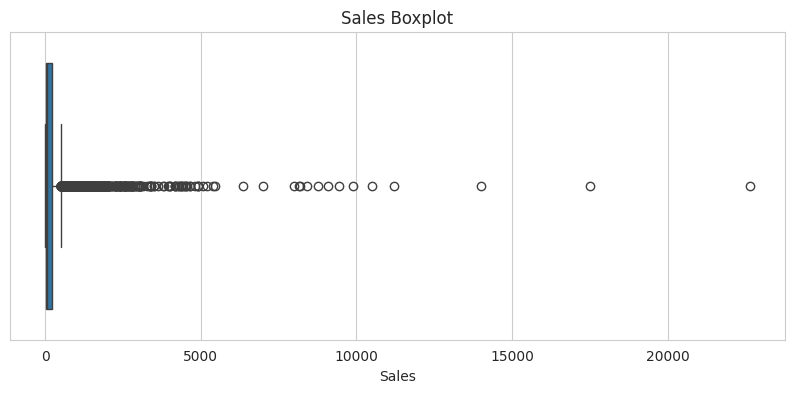

In [12]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Boxplot")
plt.show()

### Observation

The majority of sales fall within a relatively small range, while a few transactions have exceptionally large sales values.

### Business Insight

Large orders contribute disproportionately to overall sales.

### Recommendation

Identify the characteristics of high-value transactions and develop strategies to increase the frequency of similar orders.


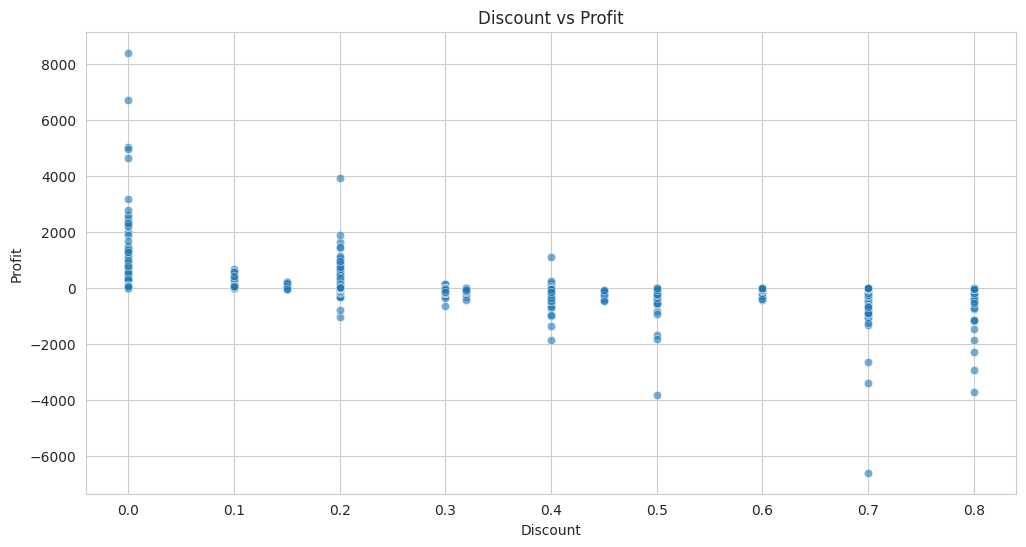

          Discount    Profit
Discount  1.000000 -0.219662
Profit   -0.219662  1.000000


In [13]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()
print(df[['Discount', 'Profit']].corr())

### Observation

The scatter plot indicates that transactions with lower discounts generally generate higher profits. As the discount percentage increases, profitable transactions become less frequent, while loss-making transactions become more common.

### Business Insight

The analysis suggests a negative relationship between discount levels and profitability. Excessive discounting may attract sales volume, but it often reduces profit margins and, in many cases, leads to financial losses.

### Recommendation

The company should review its discount strategy, particularly for discounts above 20%. Further analysis should identify which products, customer segments, and regions remain profitable under higher discount levels before implementing stricter discount policies.

In [14]:
df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

,Sales,Profit
Region,,
West,725255.6365,108329.8079
East,678435.1960,91506.3092
Central,500782.8528,39655.8752
South,391721.9050,46749.4303


### Observation

The West region has the highest sales and the highest profit.
The East region is the second-best performing region.
The South has the lowest sales.
Interestingly, the Central region has higher sales than the South but lower profit
The Central region sold more than the South but earned less profit.

### Business Insight

The Central region appears to have lower profitability despite relatively strong sales.

This suggests that sales volume alone does not guarantee higher profitability. Further analysis of discount levels, product mix, and customer segments is required to identify the factors contributing to the profitability difference.

### Recommendation

The company should investigate the Central region's:

- Discount strategy
- Product mix
- Customer segments
- Profitability by category and sub-category

In [15]:
df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741306.3133,18421.8137
Office Supplies,718735.2440,122364.6608


### Observation

Although Furniture generates high sales, it contributes very little profit compared with Technology and Office Supplies.

### Business Insight

High sales do not necessarily translate into high profitability.

Furniture has substantially lower profitability than Technology and Office Supplies. Further analysis of Furniture sub-categories, regions, and discount levels is required to identify the factors contributing to this difference.

### Recommendation

Conduct a detailed analysis of Furniture sub-categories to identify:

Loss-making products
Excessive discounting
Pricing opportunities

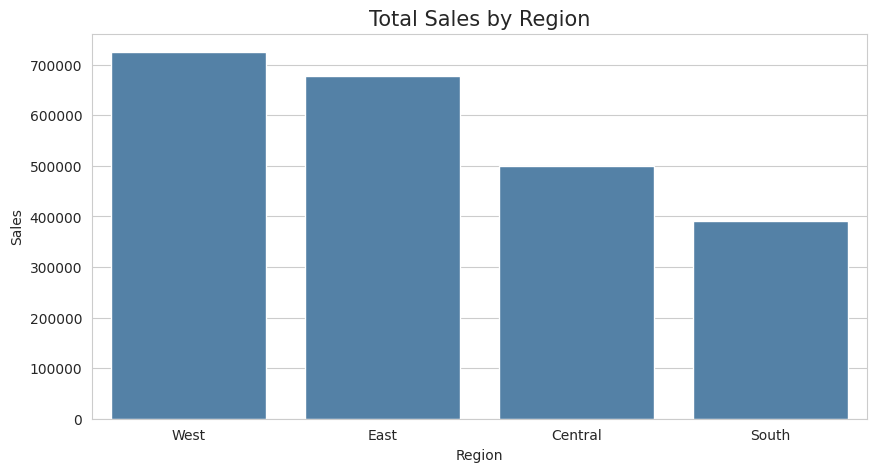

In [16]:
plt.figure(figsize=(10,5))

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    data=region_sales.reset_index(),
    x="Region",
    y="Sales",
    color="steelblue"
)
plt.title("Total Sales by Region", fontsize=15)
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

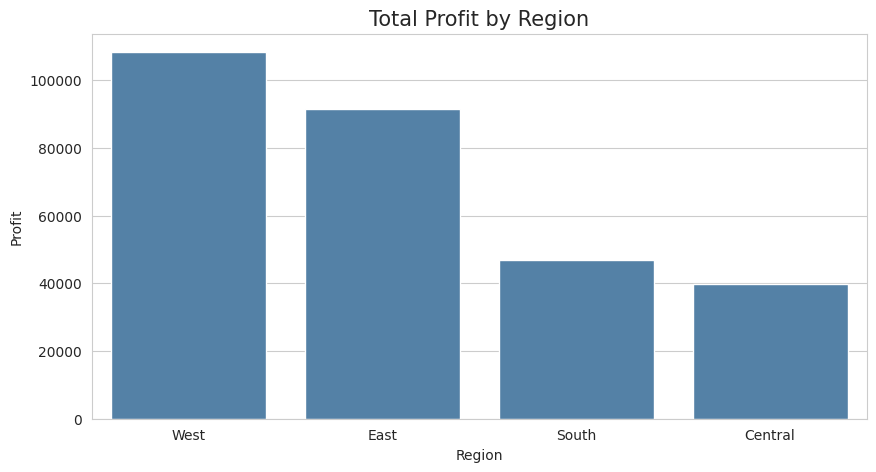

In [17]:
plt.figure(figsize=(10,5))

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

sns.barplot(
    data=region_profit.reset_index(),
    x="Region",
    y="Profit",
    color="steelblue"
)

plt.title("Total Profit by Region", fontsize=15)
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [18]:
# Furniture Sub-Category Analysis

furniture = df[df["Category"] == "Furniture"]

furniture.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Furnishings,91683.0240,13052.7230
Chairs,327777.7610,26567.1278


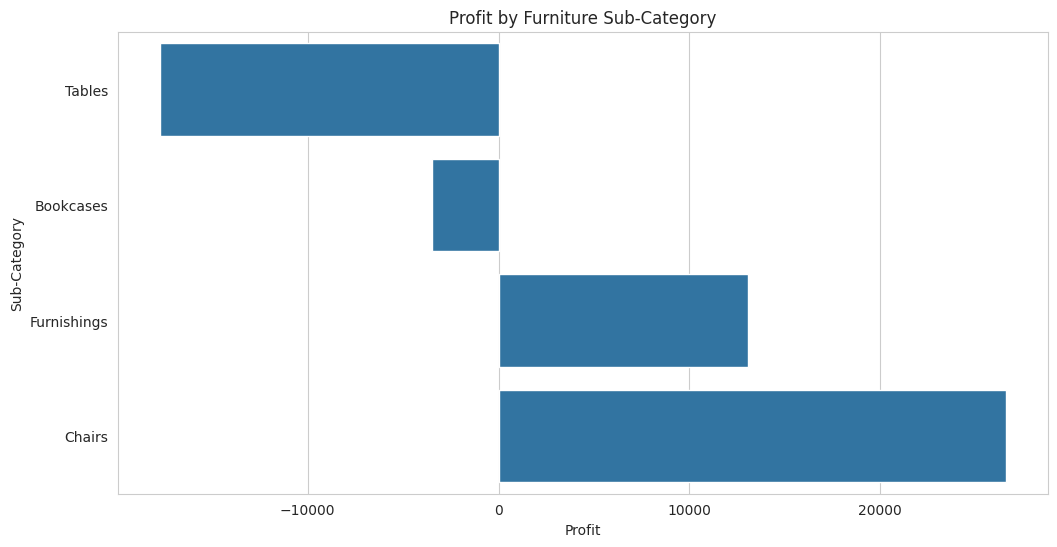

In [19]:
plt.figure(figsize=(12,6))

profit = furniture.groupby("Sub-Category")["Profit"].sum().sort_values()

sns.barplot(
    x=profit.values,
    y=profit.index
)

plt.title("Profit by Furniture Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

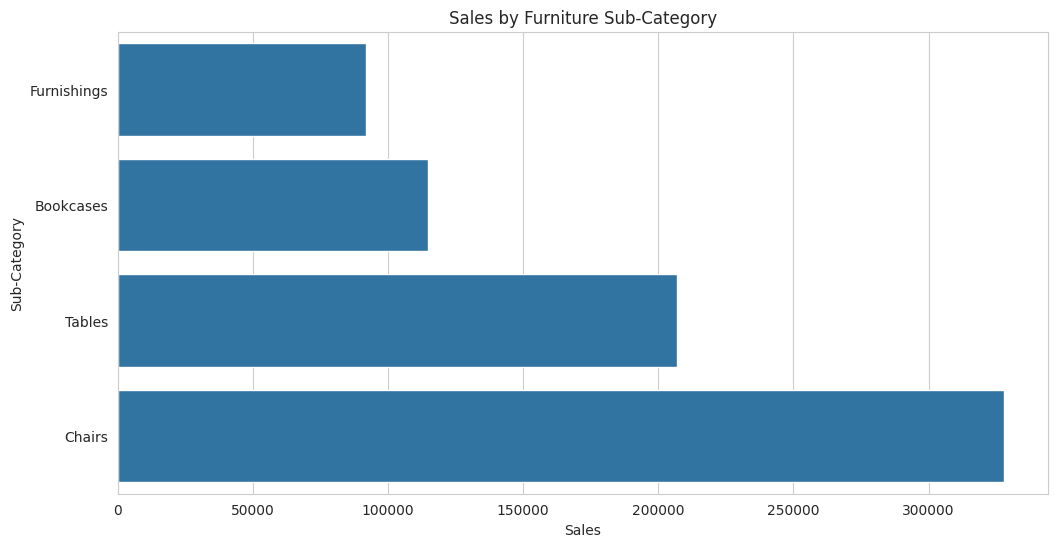

In [20]:
plt.figure(figsize=(12,6))

sales = furniture.groupby("Sub-Category")["Sales"].sum().sort_values()

sns.barplot(
    x=sales.values,
    y=sales.index
)

plt.title("Sales by Furniture Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.show()

In [21]:
tables = df[df["Sub-Category"] == "Tables"]

In [22]:
tables.shape

(319, 13)

In [23]:
tables.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,319.000000,319.000000,319.000000,319.000000,319.000000
mean,58331.749216,648.794771,3.890282,0.261285,-55.565771
std,32271.739155,615.774655,2.446381,0.169622,230.565006
min,1841.000000,24.368000,1.000000,0.000000,-1862.312400
25%,27716.000000,244.006000,2.000000,0.200000,-122.829300
50%,61107.000000,447.840000,3.000000,0.300000,-31.372200
75%,90036.000000,872.170000,5.000000,0.400000,33.851700
max,99207.000000,4297.644000,13.000000,0.500000,629.010000


In [24]:
tables[["Sales", "Discount", "Profit"]].head(10)

,Sales,Discount,Profit
3,957.5775,0.45,-383.0310
10,1706.1840,0.20,85.3092
24,1044.6300,0.00,240.2649
117,787.5300,0.00,165.3813
125,617.7000,0.50,-407.6820
201,218.7500,0.50,-161.8750
226,622.4500,0.00,136.9390
231,233.8600,0.45,-102.0480
232,620.6145,0.45,-248.2458
241,177.2250,0.50,-120.5130


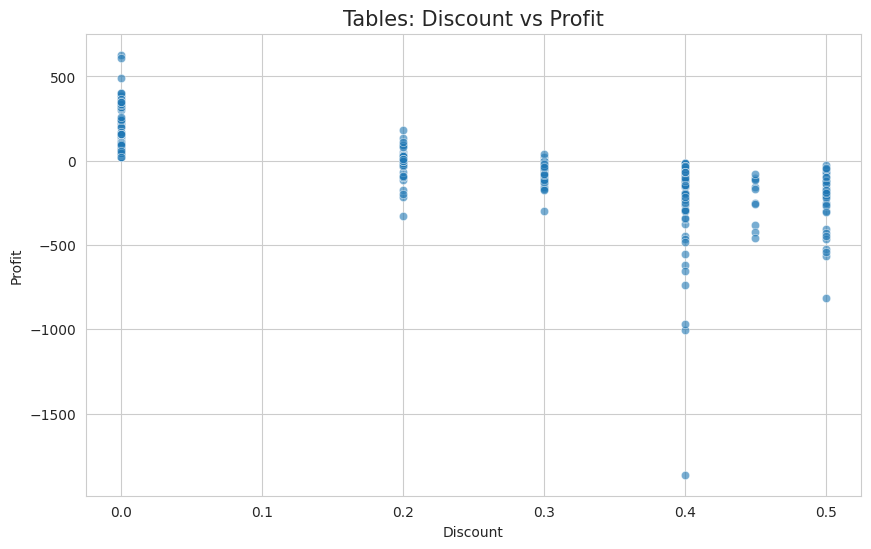

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tables,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Tables: Discount vs Profit", fontsize=15)
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [26]:
tables[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.67177
Profit,-0.67177,1.00000


In [27]:
tables.groupby("Discount")["Profit"].agg(
    ["count", "sum", "mean"]
).sort_index()

,count,sum,mean
Discount,,,
0.00,72,13276.2997,184.393051
0.20,71,-303.5580,-4.275465
0.30,54,-3402.3276,-63.006067
0.40,75,-16187.3968,-215.831957
0.45,11,-2493.1111,-226.646464
0.50,36,-8615.3873,-239.316314


In [28]:
quantity_profit = tables.groupby("Quantity")["Profit"].agg(
    ["count", "sum", "mean"]
).reset_index()

quantity_profit

,Quantity,count,sum,mean
0,1,39,-1022.3987,-26.215351
1,2,65,-1618.5738,-24.901135
2,3,81,-3780.1116,-46.668044
3,4,32,-1779.5604,-55.611263
4,5,32,-2192.9060,-68.528312
5,6,17,-2564.2224,-150.836612
6,7,25,-3039.8123,-121.592492
7,8,8,-231.7392,-28.967400
8,9,12,407.0097,33.917475
9,10,3,66.3790,22.126333


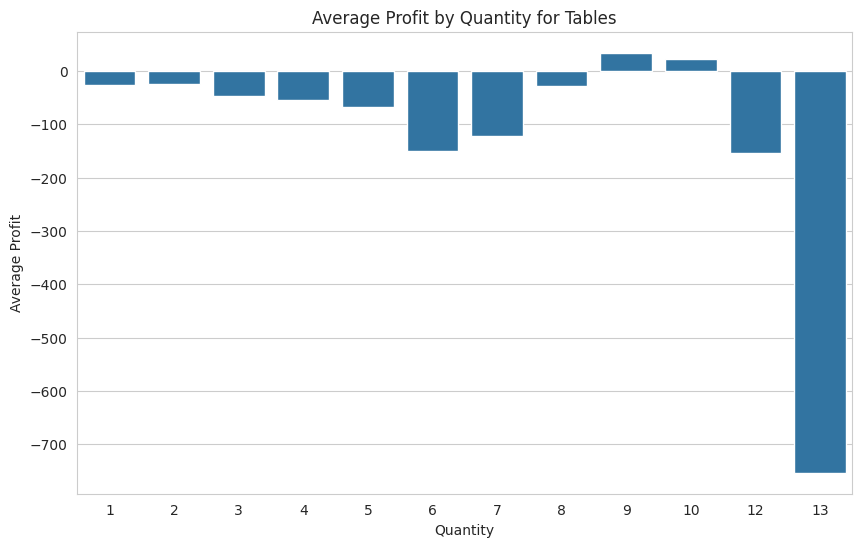

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=quantity_profit,
    x="Quantity",
    y="mean"
)

plt.title("Average Profit by Quantity for Tables")
plt.xlabel("Quantity")
plt.ylabel("Average Profit")

plt.show()

In [30]:
discount_profit = tables.groupby("Discount")["Profit"].agg(
    ["count", "sum", "mean"]
).reset_index()

discount_profit

,Discount,count,sum,mean
0,0.00,72,13276.2997,184.393051
1,0.20,71,-303.5580,-4.275465
2,0.30,54,-3402.3276,-63.006067
3,0.40,75,-16187.3968,-215.831957
4,0.45,11,-2493.1111,-226.646464
5,0.50,36,-8615.3873,-239.316314


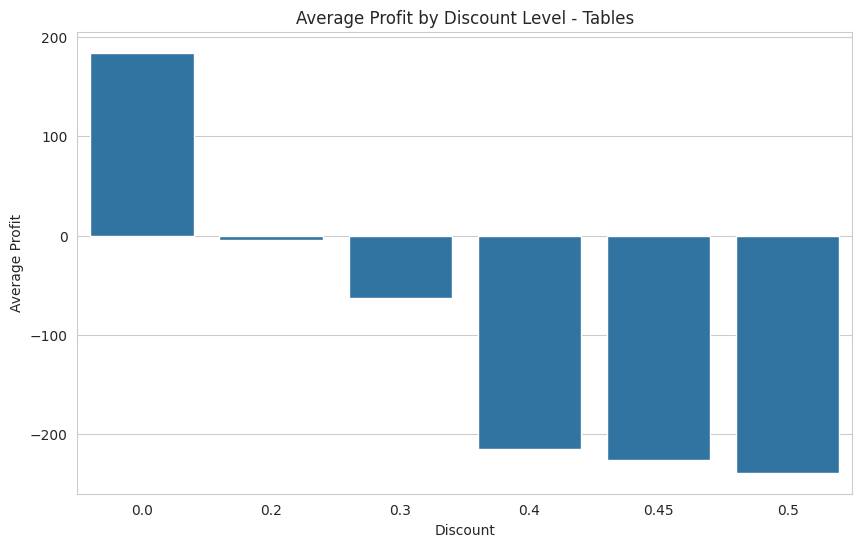

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=discount_profit,
    x="Discount",
    y="mean"
)

plt.title("Average Profit by Discount Level - Tables")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

In [32]:
table_summary = tables.agg({
    "Sales": "sum",
    "Profit": "sum"
})

table_summary["Profit Margin"] = (
    table_summary["Profit"] / table_summary["Sales"]
) * 100

table_summary

Sales            206965.53200
Profit           -17725.48110
Profit Margin        -8.56446
dtype: float64

## Tables Sub-Category Profitability Analysis

The Tables sub-category generated approximately $207K in sales but incurred a loss of approximately $17.7K, resulting in a negative profit margin of 8.56%.

The discount analysis shows a strong negative association between discount levels and profitability. Transactions with no discount generated approximately $13.3K in total profit, while transactions with a 20% discount resulted in a small overall loss. Profitability declined further at higher discount levels, with 40% discount transactions generating approximately **$16.2K** in losses.

Although some higher-quantity orders show positive average profit, these groups contain relatively few transactions. Therefore, there is insufficient evidence to recommend a specific quantity or bundle size based solely on quantity.

### Business Insight

The primary profitability concern for Tables appears to be associated with the discounting strategy. Higher discount levels are associated with increasingly negative profitability.

### Recommendation

The company should review the discount strategy for Tables and avoid applying high discounts uniformly. Discount decisions should consider product cost, demand, competitive pricing, and historical profitability. Further analysis should identify whether specific Table products, regions, or customer segments are responsible for the losses.

## Customer Segment Analysis

### Business Question

Which customer segments generate the highest sales and profit, and which segment should the company prioritize for future growth?

In [33]:
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values(
    by="Sales", ascending=False
)

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.160833e+06,134007.4413
Corporate,7.060701e+05,91954.9798
Home Office,4.292927e+05,60279.0015


In [34]:
segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
) * 100

segment_analysis

,Sales,Profit,Profit Margin (%)
Segment,,,
Consumer,1.160833e+06,134007.4413,11.544078
Corporate,7.060701e+05,91954.9798,13.023491
Home Office,4.292927e+05,60279.0015,14.041470


### Observation

- The Consumer segment generates the highest total sales and profit.
- The Home Office segment generates the lowest total sales and profit.
- Sales and profit rankings are consistent across all three segments:
  Consumer > Corporate > Home Office.

### Business Insight

Although the Home Office segment generates the lowest total sales and profit, it has the highest profit margin at 14.04%. This indicates that the segment is relatively efficient at converting sales into profit.

The Consumer segment generates the highest sales and total profit but has the lowest profit margin at 11.54%.

This suggests that increasing sales in the Home Office segment could be an opportunity for growth, provided the company can maintain its current profitability.

### Recommendation

The company should investigate opportunities to increase sales within the Home Office segment while maintaining its relatively strong 14.04% profit margin.

Further analysis should identify which products, regions, and customer behaviors contribute to this strong margin and determine whether these strategies can be scaled.

The Consumer segment should also be reviewed because, despite generating the highest sales and profit, it has the lowest profit margin among the three segments.

In [35]:
segment_category = df.groupby(
    ["Segment", "Category"]
)[["Sales", "Profit"]].sum()

segment_category

Sales      Profit
Segment     Category                                
Consumer    Furniture        390659.3420   6955.9813
            Office Supplies  363773.5360  56253.6504
            Technology       406399.8970  70797.8096
Corporate   Furniture        229019.7858   7584.8158
            Office Supplies  230600.2260  40203.1660
            Technology       246450.1190  44166.9980
Home Office Furniture        121627.1855   3881.0166
            Office Supplies  124361.4820  25907.8444
            Technology       183304.0170  30490.1405

In [36]:
segment_category["Profit Margin (%)"] = (
    segment_category["Profit"] / segment_category["Sales"]
) * 100

segment_category

Sales      Profit  Profit Margin (%)
Segment     Category                                                   
Consumer    Furniture        390659.3420   6955.9813           1.780575
            Office Supplies  363773.5360  56253.6504          15.463920
            Technology       406399.8970  70797.8096          17.420725
Corporate   Furniture        229019.7858   7584.8158           3.311860
            Office Supplies  230600.2260  40203.1660          17.434140
            Technology       246450.1190  44166.9980          17.921273
Home Office Furniture        121627.1855   3881.0166           3.190912
            Office Supplies  124361.4820  25907.8444          20.832692
            Technology       183304.0170  30490.1405          16.633646

In [37]:
furniture_discount = df[df["Category"] == "Furniture"]

furniture_discount.groupby("Discount")[["Sales", "Profit"]].sum()

,Sales,Profit
Discount,,
0.00,255613.1600,58091.5585
0.10,46634.2470,7111.0119
0.15,27558.5215,1418.9915
0.20,216631.0160,6265.9491
0.30,99188.9780,-10683.2581
0.32,14493.4588,-2391.1377
0.40,45614.4060,-16187.3968
0.45,5484.9740,-2493.1111
0.50,20983.4700,-12871.1990


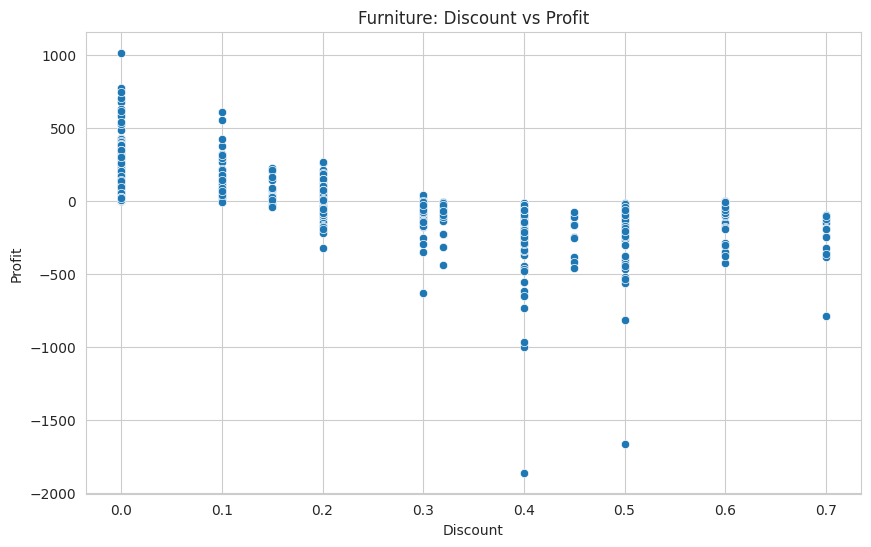

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=furniture_discount,
    x="Discount",
    y="Profit"
)

plt.title("Furniture: Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Furniture Discount Analysis

The analysis indicates that Furniture transactions become increasingly loss-making at higher discount levels, particularly around 30% and above. This pattern is consistent with the overall relationship observed between discount and profit.

However, discounting should not be considered the sole cause of Furniture's low profitability without further analysis. Other factors such as sub-category, region, and product-level performance should also be investigated.

In [39]:
furniture_region = furniture.groupby("Region")[["Sales", "Profit"]].sum()

furniture_region

,Sales,Profit
Region,,
Central,163407.1938,-2906.1467
East,208009.8320,3058.2246
South,117298.6840,6771.2061
West,252590.6035,11498.5297


In [40]:
furniture_region_sub = furniture.groupby(
    ["Region", "Sub-Category"]
)[["Sales", "Profit"]].sum()

furniture_region_sub

Sales      Profit
Region  Sub-Category                         
Central Bookcases      24157.1768  -1997.9043
        Chairs         84840.6760   6557.6248
        Furnishings    15254.3700  -3906.2168
        Tables         39154.9710  -3559.6504
East    Bookcases      43819.3340  -1167.6318
        Chairs         95979.3110   9369.8294
        Furnishings    29071.3800   5881.4071
        Tables         39139.8070 -11025.3801
South   Bookcases      10899.3620   1339.4918
        Chairs         45176.4460   6612.0893
        Furnishings    17306.6840   3442.6829
        Tables         43916.1920  -4623.0579
West    Bookcases      36004.1235  -1646.5117
        Chairs        101781.3280   4027.5843
        Furnishings    30050.5900   7634.8498
        Tables         84754.5620   1482.6073

In [41]:
furniture_region["Profit Margin (%)"] = (
    furniture_region["Profit"] / furniture_region["Sales"]
) * 100

furniture_region

,Sales,Profit,Profit Margin (%)
Region,,,
Central,163407.1938,-2906.1467,-1.778469
East,208009.8320,3058.2246,1.470231
South,117298.6840,6771.2061,5.772619
West,252590.6035,11498.5297,4.552240


In [42]:
furniture_region_sub = furniture.groupby(
    ["Region", "Sub-Category"]
)[["Sales", "Profit"]].sum()

furniture_region_sub

Sales      Profit
Region  Sub-Category                         
Central Bookcases      24157.1768  -1997.9043
        Chairs         84840.6760   6557.6248
        Furnishings    15254.3700  -3906.2168
        Tables         39154.9710  -3559.6504
East    Bookcases      43819.3340  -1167.6318
        Chairs         95979.3110   9369.8294
        Furnishings    29071.3800   5881.4071
        Tables         39139.8070 -11025.3801
South   Bookcases      10899.3620   1339.4918
        Chairs         45176.4460   6612.0893
        Furnishings    17306.6840   3442.6829
        Tables         43916.1920  -4623.0579
West    Bookcases      36004.1235  -1646.5117
        Chairs        101781.3280   4027.5843
        Furnishings    30050.5900   7634.8498
        Tables         84754.5620   1482.6073

In [43]:
furniture_region_sub["Profit Margin (%)"] = (
    furniture_region_sub["Profit"] /
    furniture_region_sub["Sales"]
) * 100

furniture_region_sub

Sales      Profit  Profit Margin (%)
Region  Sub-Category                                            
Central Bookcases      24157.1768  -1997.9043          -8.270438
        Chairs         84840.6760   6557.6248           7.729341
        Furnishings    15254.3700  -3906.2168         -25.607198
        Tables         39154.9710  -3559.6504          -9.091184
East    Bookcases      43819.3340  -1167.6318          -2.664650
        Chairs         95979.3110   9369.8294           9.762343
        Furnishings    29071.3800   5881.4071          20.230918
        Tables         39139.8070 -11025.3801         -28.169224
South   Bookcases      10899.3620   1339.4918          12.289635
        Chairs         45176.4460   6612.0893          14.636143
        Furnishings    17306.6840   3442.6829          19.892216
        Tables         43916.1920  -4623.0579         -10.527001
West    Bookcases      36004.1235  -1646.5117          -4.573120
        Chairs        101781.3280   4027.5843           3.957095
        Furnishings    30050.5900   7634.8498          25.406655
        Tables         84754.5620   1482.6073           1.749295

### Business Recommendation

Tables and Bookcases require further investigation because they contribute substantially to Furniture's profitability problem across multiple regions.

The company should analyze product-level performance, discount levels, and regional differences within these sub-categories before deciding whether to change pricing, discount policies, or product strategy.

In [44]:
tables_bookcases = df[
    df["Sub-Category"].isin(["Tables", "Bookcases"])
]

tables_bookcases.groupby(
    ["Sub-Category", "Discount"]
)[["Sales", "Profit"]].sum()

Sales      Profit
Sub-Category Discount                        
Bookcases    0.00      31935.9800   6075.7117
             0.15      27558.5215   1418.9915
             0.20      26841.4960    130.5022
             0.30       4282.6980   -555.8726
             0.32      14493.4588  -2391.1377
             0.50       7308.4600  -4255.8117
             0.70       2459.3820  -3894.9394
Tables       0.00      71578.7600  13276.2997
             0.20      45430.2320   -303.5580
             0.30      25182.1500  -3402.3276
             0.40      45614.4060 -16187.3968
             0.45       5484.9740  -2493.1111
             0.50      13675.0100  -8615.3873

### Observation

- Both Tables and Bookcases generate higher profits at lower discount levels.
- Bookcases become loss-making around a 30% discount.
- Tables become loss-making at approximately a 20% discount.
- Higher discount levels are associated with increasingly negative profitability, particularly for Tables.

### Business Insight

Discounting appears to be an important factor associated with the low profitability of Furniture, particularly for Tables and Bookcases. Tables appear more sensitive to discounts because profitability becomes negative from approximately 20% discount onward, while Bookcases remain approximately profitable up to 20%.

### Recommendation

The company should establish subcategory-specific discount limits rather than applying the same discount policy to all Furniture products. Higher discounts on Tables should be carefully restricted, while discounts on Bookcases should also be monitored as they become loss-making at higher levels.

Management should investigate why high discounts are being offered and evaluate whether promotional discounts generate sufficient additional sales to justify the reduction in profit.

In [45]:
discount_analysis = tables_bookcases.groupby(
    ["Sub-Category", "Discount"]
)[["Sales", "Profit"]].sum()

discount_analysis["Profit Margin (%)"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"]
) * 100

discount_analysis

Sales      Profit  Profit Margin (%)
Sub-Category Discount                                           
Bookcases    0.00      31935.9800   6075.7117          19.024660
             0.15      27558.5215   1418.9915           5.149012
             0.20      26841.4960    130.5022           0.486196
             0.30       4282.6980   -555.8726         -12.979496
             0.32      14493.4588  -2391.1377         -16.498047
             0.50       7308.4600  -4255.8117         -58.231306
             0.70       2459.3820  -3894.9394        -158.370656
Tables       0.00      71578.7600  13276.2997          18.547820
             0.20      45430.2320   -303.5580          -0.668185
             0.30      25182.1500  -3402.3276         -13.510870
             0.40      45614.4060 -16187.3968         -35.487466
             0.45       5484.9740  -2493.1111         -45.453472
             0.50      13675.0100  -8615.3873         -63.000958

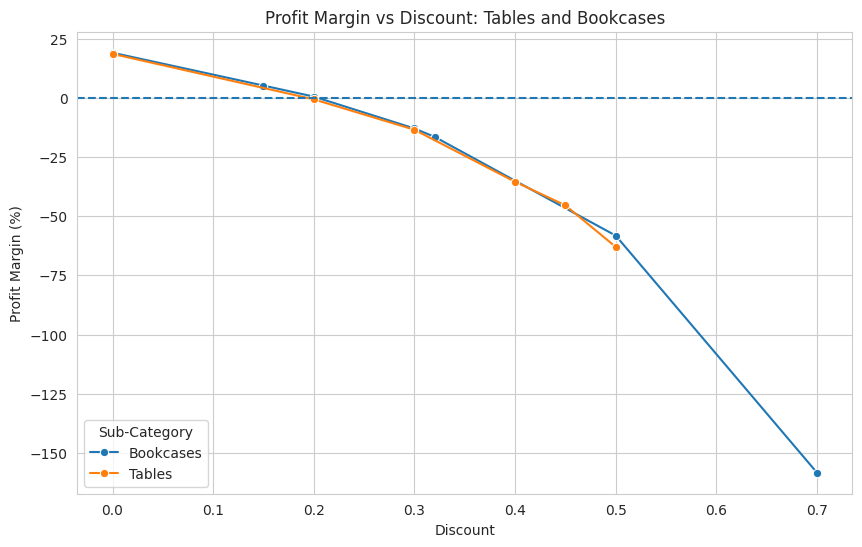

In [46]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=discount_analysis.reset_index(),
    x="Discount",
    y="Profit Margin (%)",
    hue="Sub-Category",
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Profit Margin vs Discount: Tables and Bookcases")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")

plt.show()

### Observations

- Tables have an approximately 18.55% profit margin with no discount.
- Tables become approximately unprofitable at a 20% discount.
- Bookcases have an approximately 19.02% margin with no discount.
- Bookcases approach break-even at 20% discount and become clearly loss-making at 30%.
- Tables are more sensitive to discounting than Bookcases.

# Executive Summary

This analysis evaluated sales, profitability, customer segments, regional performance, product categories, and discount patterns using the Superstore dataset.

### Key Findings

- The **Consumer segment** generates the highest total sales and profit, while **Home Office has the highest profit margin** at approximately 14.04%.
- **Furniture** has substantially weaker profitability than Technology and Office Supplies.
- **Tables and Bookcases** are major contributors to the Furniture profitability problem.
- **Tables become approximately unprofitable at a 20% discount**, while Bookcases become clearly loss-making at higher discount levels.
- Higher discount levels are strongly associated with declining profit margins in these Furniture sub-categories.

### Business Recommendations

- Implement **sub-category-specific discount policies** rather than applying a uniform discount strategy.
- Closely review high-discount transactions, particularly for Tables.
- Investigate the underlying causes of Furniture's low profitability.
- Explore opportunities to increase sales in the Home Office segment while maintaining its relatively strong profit margin.

### Conclusion

The analysis demonstrates that evaluating sales alone can hide important profitability patterns. Combining sales, profit, profit margin, customer segment, region, sub-category, and discount analysis provides a more complete view of business performance and supports more informed decision-making.